# Required Packages

In [50]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import pandas as pd
import os
import numpy as np
import scipy as sp
import scipy.constants as constant
import scipy.integrate as integrate



# Deriving Polymer Mobilities from Spectroelectrochemical Measurements

I have a note on this in my Obsidian Vault under Concepts, though I will be working through the data here. 

## Full Spectroelectrochemical Plot

C:\Users\yeage\AppData\Local\Temp\ipykernel_12304\2435426950.py:36: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
c:\Users\yeage\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


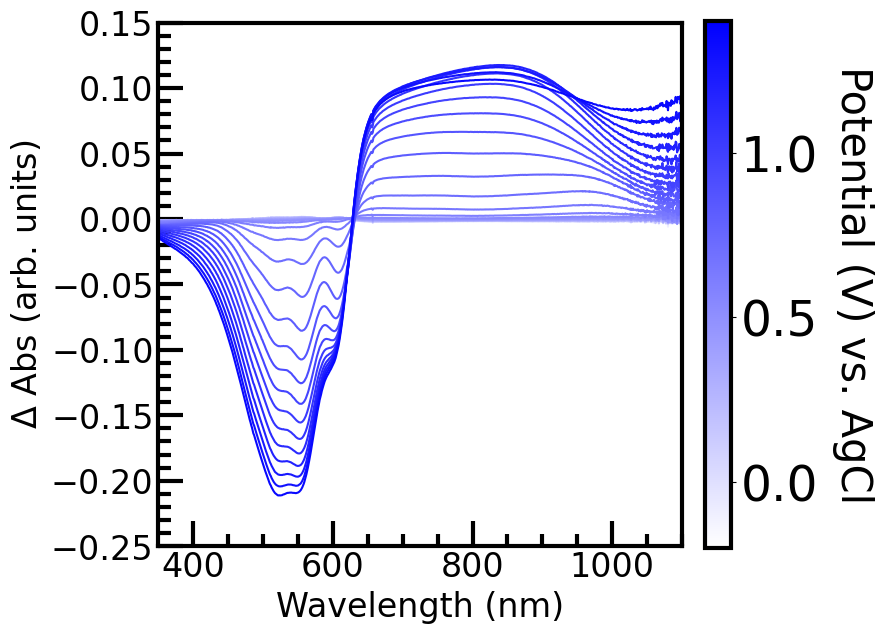

In [12]:
p3ht_no_fc = r"sample_data\spectroelectrochemistry\p3ht_100mVs.TXT"
p3ht_no_fc_load = pd.read_csv(p3ht_no_fc, skiprows=5, sep='\t')
lw = 1.5 # line width
# print(p3ht_no_fc_load)

column_num = len(p3ht_no_fc_load.columns)
# print(column_num)
ascast_cmap = LinearSegmentedColormap.from_list("", ['white', 'blue'])

reds_index = ascast_cmap(np.linspace(0, 1, column_num+1))

fontsize = 24
mpl.rcParams.update({'font.size': fontsize, 'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(9,9))
plt.rc('font', size=12)

index = 1
while index < column_num:
    ax.plot(p3ht_no_fc_load.iloc[:, 0], p3ht_no_fc_load.iloc[:, index], color=reds_index[index], linewidth=lw)
    # print(p3ht_no_fc_load.iloc[:, 0])
    index += 1

ax.set_xlim(350, 1100)
ax.set_ylim(-0.25, 0.15) 
ax.xaxis.labelpad = 5
ax.yaxis.labelpad = 5
ax.minorticks_on()
ax.tick_params(axis = 'both', direction='in', which='major', length=18, width=3)
ax.tick_params(axis = 'both', direction='in', which='minor', length=9, width=3)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("$\Delta$ Abs (arb. units)")
ax.xaxis.set_ticks((400,600,800,1000))


sm = plt.cm.ScalarMappable(cmap=ascast_cmap, norm=plt.Normalize(vmin=-0.2, vmax=1.4))
cbar = plt.colorbar(sm, fraction=0.046, pad=0.04)
cbar.set_label('Potential (V) vs. AgCl', rotation=270, labelpad=40, fontsize=30)
cbar.outline.set_linewidth(3)
cbar.ax.tick_params(labelsize=35)
# cbar.lines.set_linewidth(3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)

ax.set_box_aspect(1)

## Linecut at Polaron Lambda Max: 850 nm

c:\Users\yeage\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


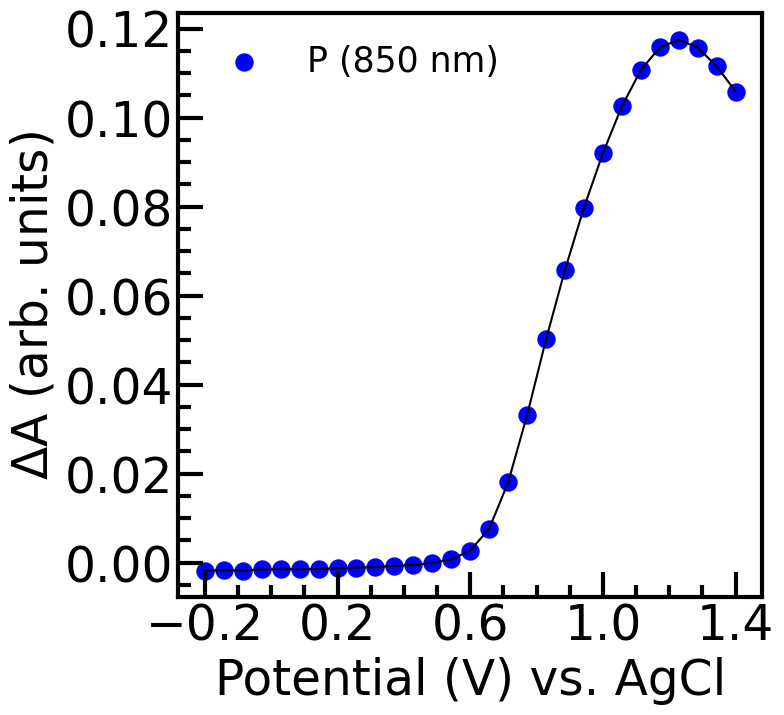

In [17]:
p3ht= r"sample_data\spectroelectrochemistry\p3ht_100mVs.TXT"
p3ht_specload = pd.read_csv(p3ht, skiprows=5, sep='\t')
p3ht_specload.head()
p3ht_color = 'blue'

p3ht_pipi = p3ht_specload.loc[p3ht_specload['WL-Time'] == 850]
p3ht_pipi.columns = p3ht_pipi.iloc[0]
p3ht_pipi_t = p3ht_pipi[1:]
p3ht_pipi_t = p3ht_pipi_t.transpose()
p3ht_pipi_t = p3ht_pipi_t.iloc[1:]
absorbance_slice = pd.DataFrame()
absorbance_slice['AU'] = p3ht_pipi_t.index
# print(p3ht_pipi_t.iloc[:])
absorbance_slice.head()



potential_scale = np.linspace(-0.2, 1.4, len(absorbance_slice))

fontsize = 35
mpl.rcParams.update({'font.size': fontsize, 'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(8,8), tight_layout=True)
plt.rc('font', size=12)

ax.scatter(potential_scale, absorbance_slice['AU'], color=p3ht_color, s=150, label="P (850 nm)")
ax.plot(potential_scale, absorbance_slice['AU'], color='black')

ax.legend(frameon=False, fontsize=25)

ax.set_xlabel("Potential (V) vs. AgCl")
ax.set_ylabel("$\Delta$A (arb. units)")

ax.xaxis.labelpad = 5
ax.yaxis.labelpad = 5
ax.tick_params(axis = 'both', direction='in', which='major', length=18, width=3)
ax.tick_params(axis = 'both', direction='in', which='minor', length=9, width=3)
ax.minorticks_on()
ax.xaxis.set_ticks((-0.2, 0.2, 0.6, 1.0, 1.4))


for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)

ax.set_box_aspect(1)

## Obtaining Capacitance through Derivative

In [22]:
p3ht= r"sample_data\spectroelectrochemistry\p3ht_100mVs.TXT"
p3ht_specload = pd.read_csv(p3ht, skiprows=5, sep='\t')
p3ht_specload.head()
p3ht_color = 'blue'

potential_scale = np.linspace(-0.2, 1.4, len(absorbance_slice))
p3ht_pipi = p3ht_specload.loc[p3ht_specload['WL-Time'] == 850]
p3ht_pipi.columns = p3ht_pipi.iloc[0]
p3ht_pipi_t = p3ht_pipi[1:]
p3ht_pipi_t = p3ht_pipi_t.transpose()
p3ht_pipi_t = p3ht_pipi_t.iloc[1:]
absorbance_slice = pd.DataFrame()
absorbance_slice['AU'] = p3ht_pipi_t.index
absorbance_slice['Potential (V)'] = potential_scale
# print(p3ht_pipi_t.iloc[:])
absorbance_slice.head()



,AU,Potential (V)
0,-0.00178,-0.200000
1,-0.00170,-0.142857
2,-0.00175,-0.085714
3,-0.00150,-0.028571
4,-0.00147,0.028571


In [28]:
diff_au = np.diff(absorbance_slice['AU'])
diff_v = np.diff(absorbance_slice['Potential (V)'])


capacitance = (diff_au / diff_v)
cap_df = pd.DataFrame()

cap_df['Capacitance (a.u.)'] = capacitance
cap_df['Potential (V)'] = absorbance_slice['Potential (V)'][:-1]

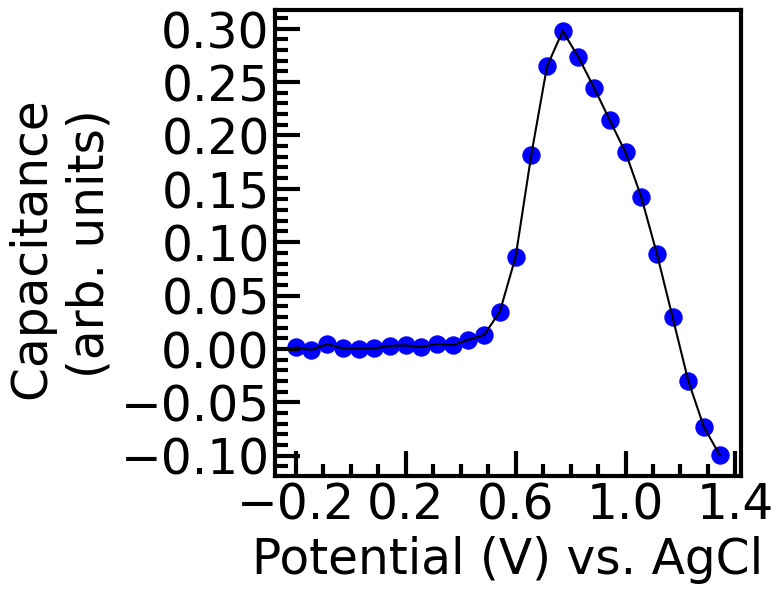

In [31]:
fontsize = 35
mpl.rcParams.update({'font.size': fontsize, 'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(8,8), tight_layout=True)
plt.rc('font', size=12)

ax.scatter(cap_df['Potential (V)'], cap_df['Capacitance (a.u.)'], color=p3ht_color, s=150, label="P (850 nm)")
ax.plot(cap_df['Potential (V)'], cap_df['Capacitance (a.u.)'], color='black')

# ax.legend(frameon=False, fontsize=25)

ax.set_xlabel("Potential (V) vs. AgCl")
ax.set_ylabel("Capacitance \n(arb. units)")

ax.xaxis.labelpad = 5
ax.yaxis.labelpad = 5
ax.tick_params(axis = 'both', direction='in', which='major', length=18, width=3)
ax.tick_params(axis = 'both', direction='in', which='minor', length=9, width=3)
ax.minorticks_on()
ax.xaxis.set_ticks((-0.2, 0.2, 0.6, 1.0, 1.4))


for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)

ax.set_box_aspect(1)

## Converting Capacitance to DOS(E)


In [38]:
arb_dos = cap_df['Capacitance (a.u.)'] / (constant.physical_constants['elementary charge'][0] ** 2)
cap_df['DOS (arb. units)'] = arb_dos
cap_df.head()


,Capacitance (a.u.),Potential (V),DOS (arb. units)
0,0.001400,-0.200000,5.453901e+34
1,-0.000875,-0.142857,-3.408688e+34
2,0.004375,-0.085714,1.704344e+35
3,0.000525,-0.028571,2.045213e+34
4,0.000175,0.028571,6.817376e+33


0        5.453901
1       -3.408688
2       17.043441
3        2.045213
4        0.681738
5        2.045213
6       10.907802
7       12.953015
8        6.817376
9       18.406916
10      13.634752
11      33.405143
12      51.130322
13     136.347524
14      335.41491
15     708.325389
16    1030.787284
17    1160.317432
18    1064.874165
19     953.069195
20     834.446849
21     717.187978
22     554.934424
23     347.004449
24     115.213658
25    -117.258871
26    -286.329801
27    -387.226969
Name: DOS (arb. units), dtype: object


c:\Users\yeage\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


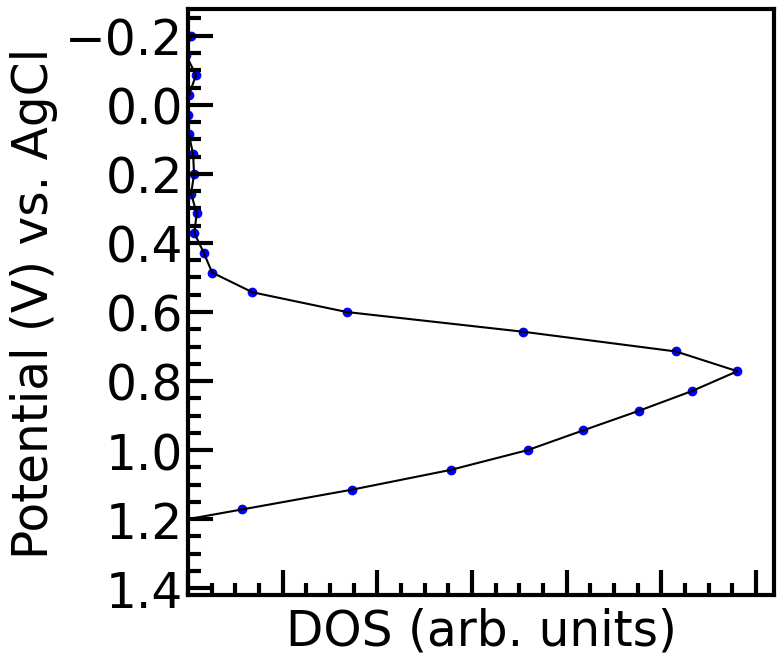

In [49]:
fontsize = 35
mpl.rcParams.update({'font.size': fontsize, 'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(8,8), tight_layout=True)
plt.rc('font', size=12)

dos = cap_df['DOS (arb. units)'] / 10**34

print(dos)
ax.scatter(dos, cap_df['Potential (V)'], color='blue')
ax.plot(dos, cap_df['Potential (V)'], color='black')

# ax.legend(frameon=False, fontsize=25)

ax.set_xlabel("DOS (arb. units)")
ax.set_ylabel("Potential (V) vs. AgCl")

ax.set_xticklabels([])
ax.set_xlim(0)
ax.invert_yaxis()
ax.xaxis.labelpad = 5
ax.yaxis.labelpad = 5
ax.tick_params(axis = 'both', direction='in', which='major', length=18, width=3)
ax.tick_params(axis = 'both', direction='in', which='minor', length=9, width=3)
ax.minorticks_on()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)

ax.set_box_aspect(1)

## Getting Hole Density

This is integrating the DOS(E) using an appoximation

In [53]:
carrier_amount = integrate.cumulative_trapezoid(cap_df['DOS (arb. units)'], cap_df['Potential (V)'])
carrier_amount = np.insert(carrier_amount, obj=0, values=np.array(0)) # adding a zero at the beginning to compensate for the dropped value in integration. Could make this NaN, but ultimately I think it's fine
log_carrier = np.log10(carrier_amount)
cap_df['Carrier Density (arb. units)'] = carrier_amount
cap_df['log Carrier'] = log_carrier

C:\Users\yeage\AppData\Local\Temp\ipykernel_12304\1387953901.py:3: RuntimeWarning: divide by zero encountered in log10
  log_carrier = np.log10(carrier_amount)


0          -inf
1     32.766670
2     33.651277
3     33.997119
4     34.029912
5     34.060401
6     34.181644
7     34.342628
8     34.441838
9     34.542402
10    34.643658
11    34.759371
12    34.911763
13    35.130909
14    35.431312
15    35.754486
16    36.027378
17    36.228169
18    36.366772
19    36.462910
20    36.533282
21    36.586302
22    36.625408
23    36.651145
24    36.663766
25    36.663711
26    36.652710
27    36.633706
Name: log Carrier, dtype: float64


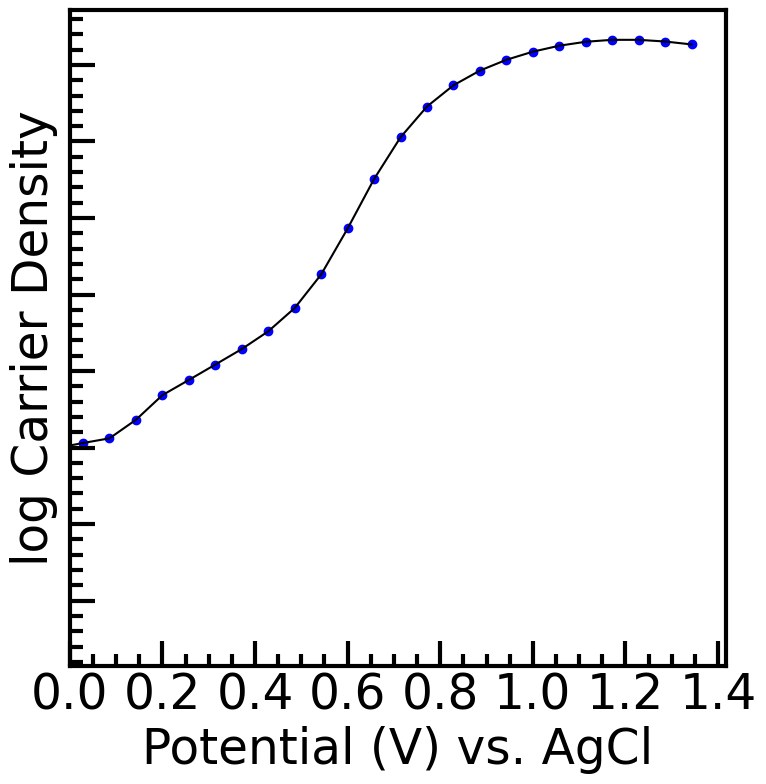

In [56]:
fontsize = 35
mpl.rcParams.update({'font.size': fontsize, 'figure.autolayout': True})
fig, ax = plt.subplots(figsize=(8,8), tight_layout=True)
plt.rc('font', size=12)

dos = cap_df['DOS (arb. units)'] / 10**34

print(cap_df['log Carrier'])
ax.scatter(cap_df['Potential (V)'], cap_df['log Carrier'], color='blue')
ax.plot(cap_df['Potential (V)'], cap_df['log Carrier'], color='black')

# ax.legend(frameon=False, fontsize=25)

ax.set_xlabel("Potential (V) vs. AgCl")
ax.set_ylabel("log Carrier Density")

ax.set_yticklabels([])
ax.set_xlim(0)
ax.xaxis.labelpad = 5
ax.yaxis.labelpad = 5
ax.tick_params(axis = 'both', direction='in', which='major', length=18, width=3)
ax.tick_params(axis = 'both', direction='in', which='minor', length=9, width=3)
ax.minorticks_on()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)

ax.set_box_aspect(1)